# Prepare

Run `generate_grid_graph_json.py` on whatever configuration you please

# Sampling
Run Julia code to sample partitions, e.g.
```
./sampling/run.sh --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1
```
On a Windows machine through Powershell, something like the following might work:
```
julia --project="sampling/runCycleWalkEnv" sampling/run_cyclewalk.jl --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1
```

# Analysis

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_shape
from hierachical import HClusters
from sample import SampleProcessor
from utils import (
    plot_district,
    plot_plan,
    plot_words_centroids,
    plot_words_list,
)
from word import PlanWordBuilder, WordStat

PRECINCT_FN = "data/graph/grid_graph_3_by_3.json"
SAMPLE_FN = "local/output/grid3x3/atlas.jsonl.gz"
OUT_DIR = "local/output/grid3x3/processed"
gdf = generate_grid_shape(3)

In [7]:
sp = SampleProcessor(PRECINCT_FN, OUT_DIR)
# run this once to process samples and dump artifacts for future use
sp.clean()
sp.process_samples([SAMPLE_FN], max_length=1000, min_step=100)
sp.load_processed()

Reading local\output\grid3x3\atlas.jsonl.gz


plans: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 11276.77it/s]


We give each district a unique `district_uid'. Districts are stored via the precincts that they contain (i.e. as an array of ints).

In [8]:
sp.df_districts.head()

,district_str,district_uid
0,0.3.6,0
1,1.4.7,1
2,2.5.8,2
3,1.2.4,3
4,5.7.8,4


Each plan is stored using `district_uid's and is given a 'plan_id'

In [9]:
sp.df_plans.head()

,step,plan_id,sample_tag,plan,plan_str
0,1000,0,atlas,"[0, 1, 2]",0.1.2
1,2000,1,atlas,"[0, 2, 1]",0.1.2
2,3000,2,atlas,"[3, 4, 0]",0.3.4
3,4000,3,atlas,"[5, 6, 7]",5.6.7
4,5000,4,atlas,"[8, 7, 9]",7.8.9


We visualize the first sampled plan and its first district

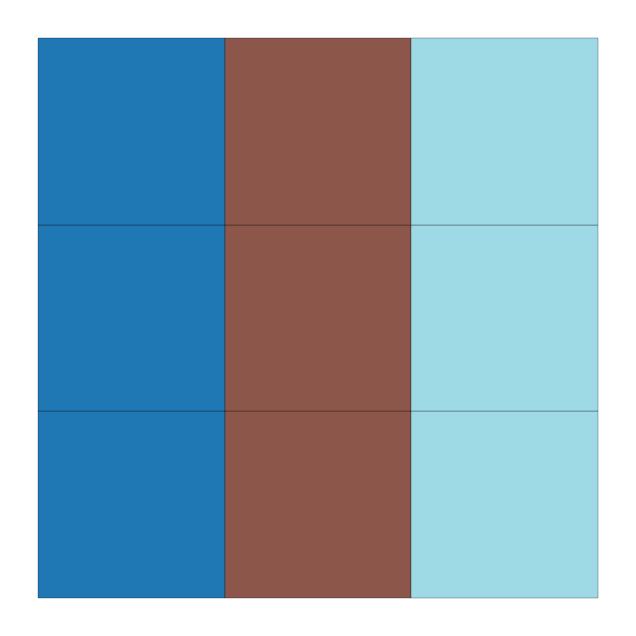

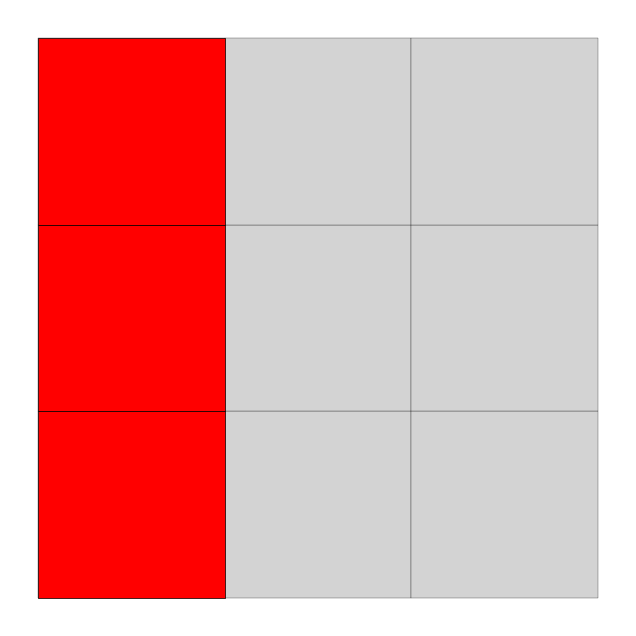

In [10]:
plan = sp.df_plans.iloc[0].plan
labels = sp.decode_plan_vector(plan)
plot_plan(gdf, labels)
plt.show()

district = sp.decode_district(plan[0])
plot_district(gdf, district)
plt.show()

Next, we run hcc and infer clusters at a given number of letters.

In [11]:
sp.load_distance_matrix()
sp.ensure_linkage()

num_letters = 20
hc = HClusters(sp)
hc.update_clusters(num_letters)
hc.kcentroids()

  2%|██                                                                                                   | 1/50 [00:00<?, ?it/s]

epoch 0: rel_improvement = 0.15384615384615385


We visualize some letters 

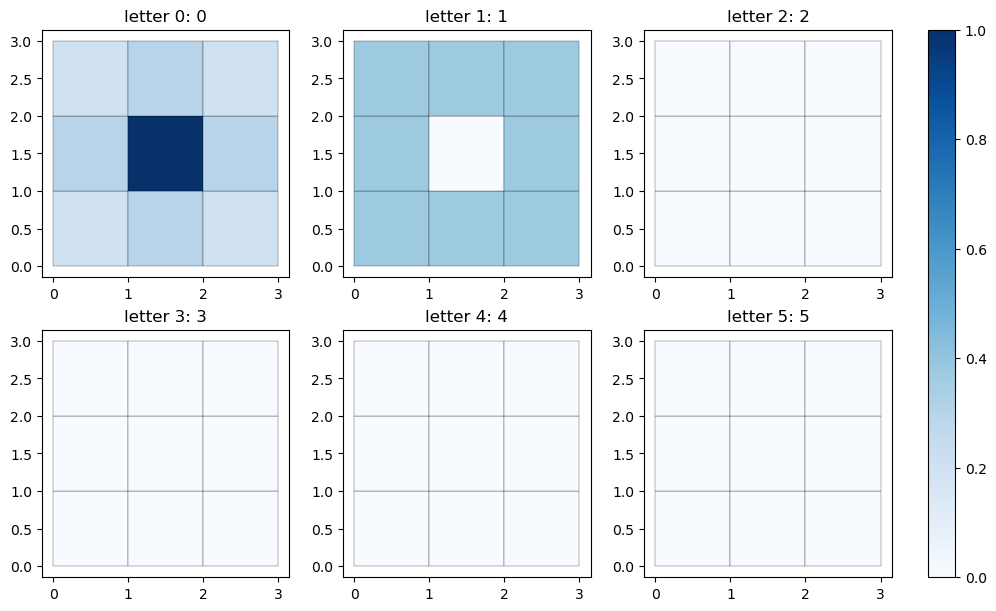

In [12]:
letters = list(range(min(6, num_letters)))
plot_words_list(gdf, hc.cluster_densities, letters, cols=3, figsize=(10, 6))
plt.show()

We then use the letters to construct words via beam search with a prescribed `word_degree'

In [13]:
pw = PlanWordBuilder(sp, hc, word_degree=10, verbose=True, centroid_norm="l1").build()
pw.df_words.head()

Enumerating words: 100%|███████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 1016.83it/s]


,plan_uid,plan,word,distance,min_distance,plan_str,word_str,word_uid
0,0,"[0, 1, 2]","[0, 1, 8]",8.0,8.0,0.1.2,0.1.8,2
1,0,"[0, 1, 2]","[0, 2, 8]",8.0,8.0,0.1.2,0.2.8,6
2,0,"[0, 1, 2]","[0, 4, 8]",8.0,8.0,0.1.2,0.4.8,12
3,0,"[0, 1, 2]","[0, 3, 8]",8.0,8.0,0.1.2,0.3.8,10
4,0,"[0, 1, 2]","[0, 2, 9]",8.0,8.0,0.1.2,0.2.9,7


We compute stationary distribution under some POU (controlled by temperature).

In [14]:
ws = WordStat(pw, temp=0.0, verbose=False)
df_top = ws.stationary_table().head(3).reset_index(drop=True)
df_top

,word_uid,word_str,word,stationary
0,0,0.1.10,"[0, 1, 10]",0.1
1,2,0.1.8,"[0, 1, 8]",0.1
2,3,0.1.9,"[0, 1, 9]",0.1


This is the flux matrix

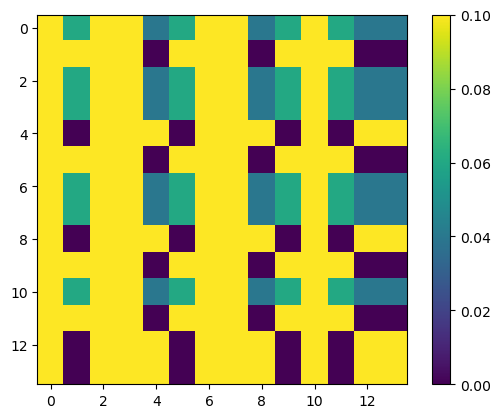

In [15]:
plt.imshow(ws.flux_matrix())
plt.colorbar()

These are some most frequent words under the stationary distribution

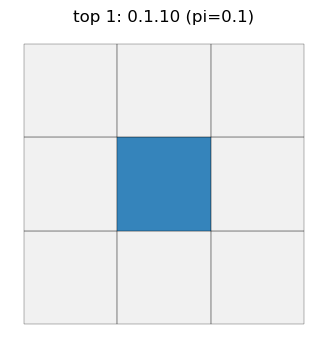

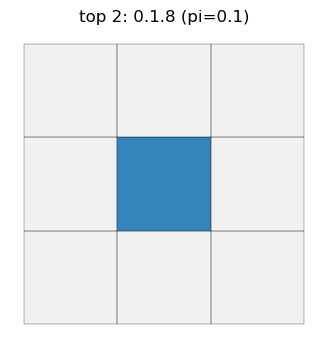

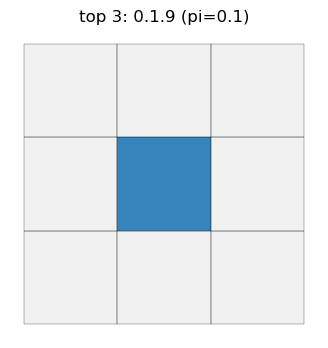

In [16]:
for i, row in df_top.iterrows():
    fig, ax = plot_words_centroids(
        gdf, hc.cluster_densities, row.word, ltr=True, figsize=(4, 4)
    )
    ax.set_title(f"top {i + 1}: {row.word_str} (pi={row.stationary:.3g})")
    plt.show()